In [1]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
import torch
from torch import nn
import pandas as pd

torch.manual_seed(123)

src_path = Path.cwd().parent / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Added to sys.path: {src_path}")
load_dotenv()  # reads .env file from the current directory

Added to sys.path: /home/jtv/code/jtviegas/languagemodels/notebook/src


True

In [2]:
from datasets import ClassLabel, Dataset, load_dataset

def setup_class_label(ds: Dataset, label_column: str = "label_text") -> Dataset:
  unique_labels = sorted(set(ds[label_column]))
  ds = ds.cast_column(label_column, ClassLabel(names=[str(x) for x in unique_labels]))
  return ds

dataset = load_dataset("FinanceMTEB/financial_phrasebank", split="train")
dataset = setup_class_label(dataset)
dataset_split = dataset.train_test_split(test_size=0.2, seed=42, stratify_by_column="label_text")
df_train = dataset_split["train"].to_pandas()
dataset_split = dataset_split["test"].train_test_split(test_size=0.5, seed=42, stratify_by_column="label_text")
df_val = dataset_split["train"].to_pandas()
df_test = dataset_split["test"].to_pandas()

del df_train["label_text"]
del df_val["label_text"]
del df_test["label_text"]

In [3]:
df_train

,text,label
0,`` The enterprise value of the Fray Bentos pul...,1
1,Stora is due to release its fourth-quarter and...,1
2,The new SEPA cads will replace Finnish bank ca...,1
3,The medium-term operative targets of the compa...,1
4,Operating profit decreased to EUR 11.2 mn from...,0
...,...,...
1006,"According to PKC , the acquisition would bring...",2
1007,The Filter Tips cover the volume range from 0....,1
1008,Teleste was set up in 1954 and is divided into...,1
1009,Each year the dividend is deducted from the su...,1


In [4]:
from tgedr_languagemodels.utils.utils_data import TextDataset
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

train_ds = TextDataset(df_train, tokenizer, text_col="text", label_col="label")
val_ds = TextDataset(df_val, tokenizer, text_col="text", label_col="label")
test_ds = TextDataset(df_test, tokenizer, text_col="text", label_col="label")


In [5]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0, drop_last=False)


In [6]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

63 training batches
8 validation batches
8 test batches


In [28]:
from pathlib import Path

PATH_DATA = Path.cwd().parent.parent / ".data"
PATH_GPT2_124M_WEIGHTS = PATH_DATA / "model_weights" / "gpt2" / "124M"
PATH_GPT2_124M_WEIGHT_SETTINGS = PATH_GPT2_124M_WEIGHTS / "settings.pickle.gz"
PATH_GPT2_124M_WEIGHTS_PARAMETERS = PATH_GPT2_124M_WEIGHTS / "parameters.pickle.gz"
PATH_GPT2_CLASSIFIER_MODEL = PATH_DATA / "models" / "gpt2_classifier.pth"

DEFAULT_CONTEXT_LENGTH = 1024
DEFAULT_STRIDE = 1

In [8]:
from tgedr_languagemodels.configuration import GPT2_MODEL_CONFIGS, BaseModelConfig
from tgedr_languagemodels.gpt2.model import GPT2Model
from tgedr_languagemodels.utils.model_weights import load_weights_into_gpt

model_name = "gpt2-small (124M)"
tokenizer = tiktoken.get_encoding("gpt2")

config: BaseModelConfig = BaseModelConfig(
    vocabulary_size=tokenizer.n_vocab,
    context_length=DEFAULT_CONTEXT_LENGTH,
    embeddings_dimension=GPT2_MODEL_CONFIGS[model_name]["emb_dim"],
    n_heads=GPT2_MODEL_CONFIGS[model_name]["n_heads"],
    n_layers=GPT2_MODEL_CONFIGS[model_name]["n_layers"],
    drop_rate=0.0,
    qkv_bias=True,
    stride=DEFAULT_STRIDE
)

model = GPT2Model(config)
model.eval()

GPT2Model(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_que

In [9]:
from tgedr_languagemodels.utils.utils_llm import load_pickle_compressed

pre_trained_params = load_pickle_compressed(PATH_GPT2_124M_WEIGHTS_PARAMETERS)
load_weights_into_gpt(model, pre_trained_params)

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cpu


GPT2Model(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_projection): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_que

In [11]:
# test the model with a dummy input
from tgedr_languagemodels.inference import generate
from tgedr_languagemodels.utils.utils_llm import text_to_token_ids, token_ids_to_text

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=15,
    context_size=config.context_length,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you forward.

The first step is to understand the importance of your work


In [12]:
# let's check how the model does classification at this stage
text_2 = "Is the following text 'neutral', 'positive' or 'negative'? 'Stora is due to release its fourth-quarter and 2009 full-year earnings on Feb. 4'"
token_ids = generate(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer).to(device),
    max_new_tokens=64,
    context_size=config.context_length,
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))
# it does not it needs training, but it is a good sign that it does not produce gibberish and instead produces a coherent continuation of the input text

Output text:
 Is the following text 'neutral', 'positive' or 'negative'? 'Stora is due to release its fourth-quarter and 2009 full-year earnings on Feb. 4'

'Stora is due to release its fourth-quarter and 2009 full-year earnings on Feb. 4' 'Stora is due to release its fourth-quarter and 2009 full-year earnings on Feb. 4' 'Stora is due to release its fourth-quarter and 2009 full-year earnings on


In [13]:
# changing the gpt2 model to a classification output
# To get the model ready for classification fine-tuning, we first freeze the model, 
# meaning that we make all layers non-trainable:

for param in model.parameters():
    param.requires_grad = False

# Then, we replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions, 
# the size of the vocabulary (see figure 6.9).

num_classes = 3
model.out_head = torch.nn.Linear(
    in_features=GPT2_MODEL_CONFIGS[model_name]["emb_dim"],
    out_features=num_classes
)
# model.out_head output layer has its requires_grad attribute set to True by default

In [14]:
# fine-tuning additional layers can noticeably improve the predictive performance of the model
# We also configure the last transformer block and the final LayerNorm module, 
# which connects this block to the output layer, to be trainable
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True


In [15]:
# let's check the outputs with a dummy input
inputs = torch.tensor(
  tokenizer.encode("Tesco is due to release its 2009 full-year earnings and it doesn't look good, sources say")
).unsqueeze(0)
print("Inputs dimensions:", inputs.shape)

Inputs dimensions: torch.Size([1, 21])


In [16]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[ -1.5162,  -1.2210,  -1.0749],
         [ -5.5392,  -2.7784,  -4.2422],
         [ -8.1551,  -3.1540,  -6.1835],
         [ -4.4998,  -2.4458,  -3.5112],
         [ -9.8886,  -3.7699,  -6.5975],
         [ -8.0210,  -3.2917,  -7.1898],
         [ -9.2640,  -3.7089,  -7.5348],
         [ -8.5933,  -4.1767,  -7.5293],
         [ -6.6935,  -3.9438,  -5.4426],
         [ -4.9782,  -2.3827,  -2.6181],
         [ -9.1555,  -4.0335,  -6.8751],
         [ -8.9296,  -4.5525,  -8.1092],
         [ -8.5342,  -3.1586,  -6.7798],
         [ -8.6315,  -4.1240,  -6.9320],
         [ -5.7417,  -4.8949,  -3.7936],
         [-10.7047,  -4.6061,  -7.3598],
         [ -7.4843,  -3.1673,  -5.8941],
         [ -6.2181,  -3.0445,  -6.3334],
         [ -8.9655,  -3.5710,  -7.3863],
         [ -7.8926,  -2.4336,  -5.5923],
         [  0.3598,   0.0544,   0.2404]]])
Outputs dimensions: torch.Size([1, 21, 3])


In [17]:
# we are just interested in the last one, which is the output of the classification head
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[0.3598, 0.0544, 0.2404]])


In [18]:
# let's calculate the loss and accuracy

probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 0


In [19]:
# or just simply use the argmax on the outputs
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 0


In [20]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)


            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]     #1
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples

In [21]:
torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device
)
val_accuracy = calc_accuracy_loader(
    val_loader, model, device
)
test_accuracy = calc_accuracy_loader(
    test_loader, model, device
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 25.50%
Validation accuracy: 26.19%
Test accuracy: 24.41%


In [22]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :]     #1
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [23]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:                                        #1
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [24]:
with torch.no_grad():                 #1
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)
print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 1.211
Validation loss: 1.222
Test loss: 1.246


In [25]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

def train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs, eval_freq, eval_iter):
    #1 Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []   
    examples_seen, global_step = 0, -1

    for epoch in range(num_epochs):    #2 Main training loop
        model.train()             #3 Sets model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                      #4 Resets loss gradients from the previous batch iteration
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()                          #5 Calculates loss gradients
            optimizer.step()                          #6 Updates model weights using loss gradients
            examples_seen += input_batch.shape[0]    #7 New: tracks examples instead of tokens
            global_step += 1

            #8 Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        #9 Calculates accuracy after each epoch
        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen


In [ ]:
import time

start_time = time.time()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=5e-5, weight_decay=0.1
)
num_epochs = 5


train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=50,
        eval_iter=5
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")


Ep 1 (Step 000000): Train loss 0.609, Val loss 0.624


KeyboardInterrupt: 

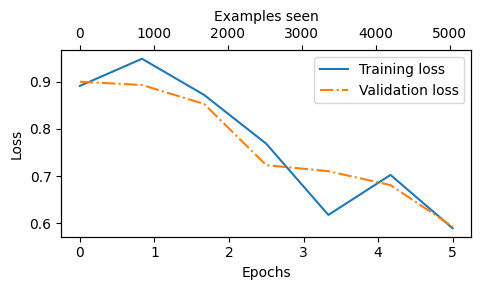

In [ ]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

 #1
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

 #2
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)    #3
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()             #4
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)
#1 Plots training and validation loss against epochs
#2 Creates a second x-axis for examples seen
#3 Invisible plot for aligning ticks
#4 Adjusts layout to make room

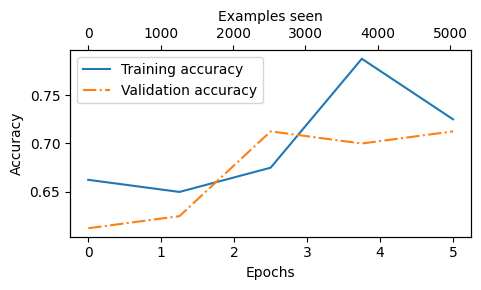

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

In [ ]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 76.49%
Validation accuracy: 74.60%
Test accuracy: 74.02%


In [31]:
# using the model to make predictions on new data

def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)          #1 Prepares inputs to the model
    supported_context_length = model.pos_emb.weight.shape[0]

    input_ids = input_ids[:min(              #2 Truncates sequences if they are too long
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))    #3 Pads sequences to the longest sequence

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)              #4 Adds batch dimension

    with torch.no_grad():                                #5 Models inference without gradient tracking
        logits = model(input_tensor)[:, -1, :]     #6 Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    return predicted_label


In [34]:
text_1 = "sources say the sales are decreasing and money is short in Tesco, hedge funds are selling its stock"

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_ds.max_length
))

1


In [ ]:

torch.save(model.state_dict(), PATH_GPT2_CLASSIFIER_MODEL)


In [29]:
model_state_dict = torch.load(PATH_GPT2_CLASSIFIER_MODEL, map_location=device)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [33]:
print(classify_review(
    "Operating profit excluding non-recurring items increased by 27 % to EUR 81.9 mn from EUR 64.4 mn in the corresponding period in 2008 .", 
    model, tokenizer, device, max_length=train_ds.max_length
))

2
